# Análisis de Fourier
## Senos y Cosenos en 2D

In [ ]:
%pip install ipywidgets

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import widget
from IPython.display import display


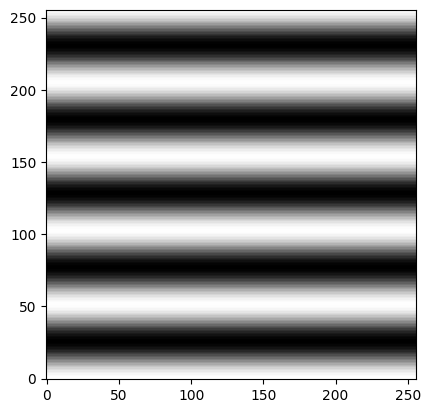

In [3]:
def sine2D(N, M, n, m, u, v, A=1):
    return A * np.sin(2*np.pi*((u*n/N) + (v*m/M)))
def cosine2D(N, M, n, m, u, v, A=1):
    return A * np.cos(2*np.pi*((u*n/N) + (v*m/M)))

def apply_func(func, matrix, u, v):
    N,M = matrix.shape
    mat_aux = np.zeros_like(matrix)
    for n in range(N):
        for m in range(M):
            mat_aux[n,m] = func(N, M, n, m, u, v)
    return (255.0 * ((mat_aux + 1) / 2)).astype(np.uint8)

N,M = (256,256)
matrix = np.zeros((N,M))
matrix_sin = apply_func(cosine2D, matrix, 5, 0)

plt.imshow(matrix_sin, cmap="gray", interpolation="nearest", origin="lower")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def generate_func(frecuencia_horizontal=0, frecuencia_vertical=0, func=0):
    N,M = (256,256)
    matrix = np.zeros((N,M))
    f = sine2D if func == 0 else cosine2D
    matrix_sin = apply_func(f, matrix, frecuencia_horizontal, frecuencia_vertical)
    plt.imshow(matrix_sin, cmap="gray", interpolation="nearest", origin="lower")
    plt.show()

widgets_interact = widgets.interactive(
    generate_func,
    frecuencia_horizontal=widgets.FloatSlider(min=0,max=20,step=0.1,value=0),
    frecuencia_vertical=widgets.FloatSlider(min=0,max=20,step=0.1,value=0),
    func=widgets.ToggleButtons(
        options=[('Seno',0),('Coseno',1)]
    )
)

display(widgets_interact)

## Transformada de Fourier 2D

In [4]:
def get_fft(image, log=True, padding=None):
    if padding:
        fft = np.fft.fft2(image, s=padding)
    else:
        fft = np.fft.fft2(image)
    fft_shifted = np.fft.fftshift(fft) # Se mueve la frecuencia 0 (DC) al centro de la imagen
    #fft_spectrum = 20*np.log(np.abs(fft_shifted)) # Espectro - Módulo en escala logarítmica
    if log: 
        return np.log(np.abs(fft_shifted) + 1)
    return np.abs(fft_shifted)

In [ ]:
fft_image = get_fft(matrix_sin, False)

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].imshow(matrix_sin, cmap="gray", interpolation="nearest", origin="lower")
axs[1].imshow(fft_image, cmap="gray")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def generate_func(frecuencia_horizontal=0, frecuencia_vertical=0, func=0):
    N,M = (256,256)
    matrix = np.zeros((N,M))
    f = sine2D if func == 0 else cosine2D
    matrix_sin = apply_func(f, matrix, frecuencia_horizontal, frecuencia_vertical)
    fft_image = get_fft(matrix_sin, False)

    fig, axs = plt.subplots(1, 2, figsize=(12,5))
    axs[0].imshow(matrix_sin, cmap="gray", interpolation="nearest", origin="lower")
    axs[1].imshow(fft_image, cmap="gray")
    plt.show()

widgets_interact = widgets.interactive(
    generate_func,
    frecuencia_horizontal=widgets.FloatSlider(min=-30,max=30,step=0.1,value=0),
    frecuencia_vertical=widgets.FloatSlider(min=-30,max=30,step=0.1,value=0),
    func=widgets.ToggleButtons(
        options=[('Seno',0),('Coseno',1)]
    )
)

display(widgets_interact)
# Cudrículas por alisiang - El número de pixeles debe cumplir con el teorema de Nyquist.

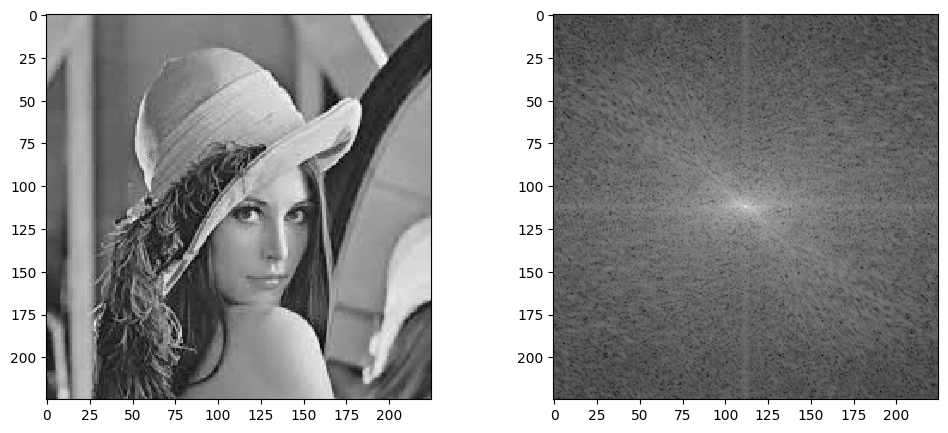

In [5]:
img = cv2.imread("img/lena.jpeg", cv2.IMREAD_GRAYSCALE)
fft_image = get_fft(img, True)
fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].imshow(img, cmap="gray", interpolation="nearest")
axs[1].imshow(fft_image, cmap="gray")
plt.show()

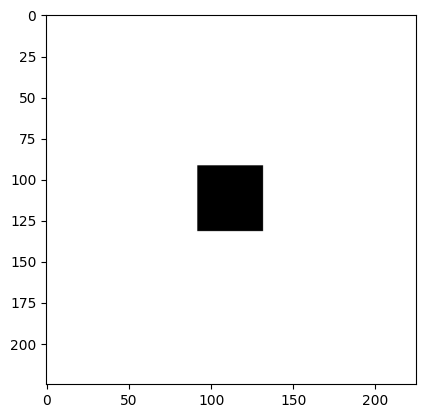

In [6]:
h, w = fft_image.shape
u, w = h//2, w//2
pad = 20

high_pass_filter = 1.0 * np.ones_like(fft_image)
high_pass_filter[u-pad:u+pad, w-pad:w+pad] = 0.0

plt.imshow(high_pass_filter.astype(np.uint8), cmap="gray")
plt.show()

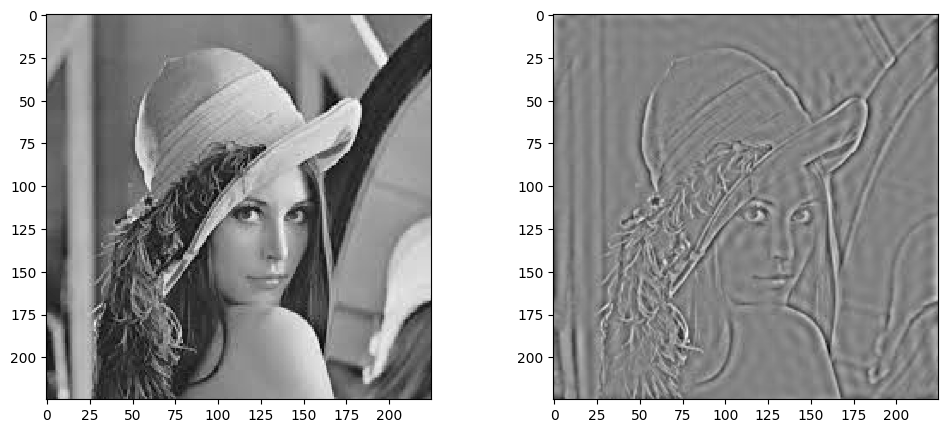

In [7]:
fft_img = np.fft.fft2(img)
fft_img = np.fft.fftshift(fft_img)
image_filtered = np.multiply(fft_img, high_pass_filter)
image_filtered = np.fft.ifftshift(image_filtered)
image_filtered = np.real(np.fft.ifft2(image_filtered))

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].imshow(img, cmap="gray", interpolation="nearest")
axs[1].imshow(image_filtered, cmap="gray")
plt.show()


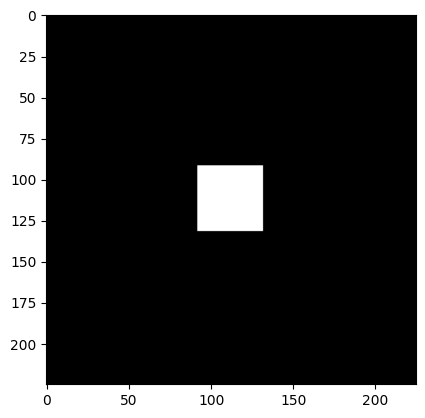

In [12]:
h, w = fft_image.shape
u, w = h//2, w//2
pad = 20

low_pass_filter = 1.0 * np.zeros_like(fft_image)
low_pass_filter[u-pad:u+pad, w-pad:w+pad] = 1.0

plt.imshow(low_pass_filter.astype(np.uint8), cmap="gray")
plt.show()

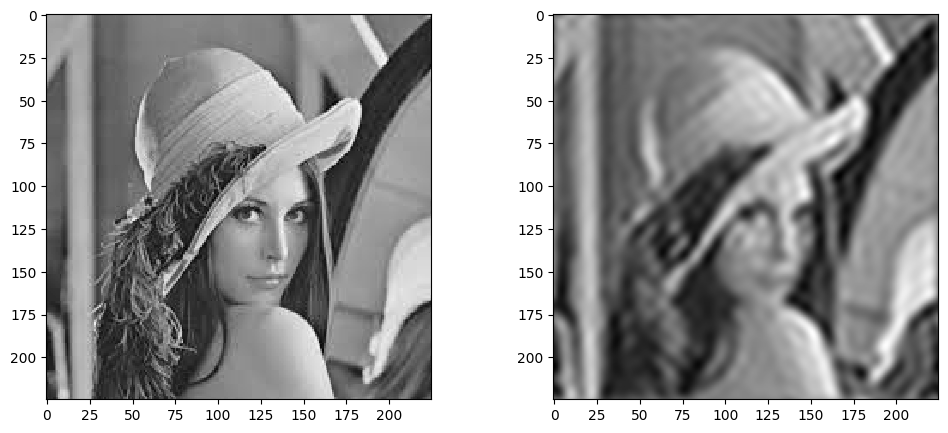

In [13]:
fft_img = np.fft.fft2(img)
fft_img = np.fft.fftshift(fft_img)
image_filtered = np.multiply(fft_img, low_pass_filter)
image_filtered = np.fft.ifftshift(image_filtered)
image_filtered = np.real(np.fft.ifft2(image_filtered))

fig, axs = plt.subplots(1, 2, figsize=(12,5))
axs[0].imshow(img, cmap="gray", interpolation="nearest")
axs[1].imshow(image_filtered, cmap="gray")
plt.show()

In [15]:
kernel_sobel = (1/8) * np.asmatrix([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
    ], dtype=np.float32)

kernel_bilineal = (1/16) * np.asmatrix([
    [1,2,1],
    [2,4,2],
    [1,2,1]
    ], dtype=np.float32)

K = 3
kernel_box = (1/(K**2))*np.ones(shape=(K,K))

kernel_gaussian = (1/256) * np.asmatrix([
    [1,4,6,4,1],
    [4,16,24,16,4],
    [6,24,36,24,6],
    [4,16,24,16,4],
    [1,4,6,4,1]
    ],dtype=np.float32)

kernel_corner = (1/4) * np.asmatrix([
    [1,-2,1],
    [-2,4,-2],
    [1,-2,1]
    ], dtype=np.float32)

kernel_sharpening = (1/4) * np.asmatrix([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
    ], dtype=np.float32)

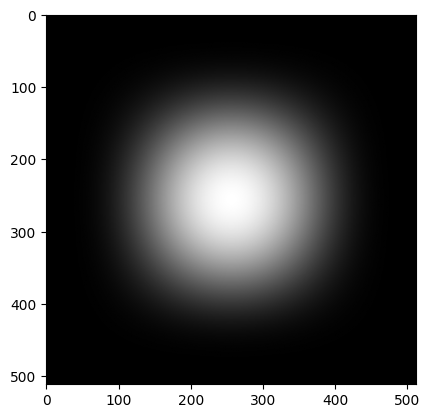

In [17]:
filter = kernel_gaussian
fft_img = get_fft(filter, True, padding=(512,512))
plt.imshow(fft_img, cmap="gray")
plt.show()

### Tarea
* Calcular y mostrar la transformada de Fourier para cada uno de los filtros lineales que hemos visto en clase.
* Interpretar la imagen de la transformada de Fourier, estableciendo si corresponde a un filtro pasa altas o pasa bajas.

In [ ]:
img = cv2.imread("img/lena.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
img = img[:,:,0]
img.shape

In [ ]:
img = np.float32(img)
img_dft =  cv2.dft(img, flags = cv2.DFT_COMPLEX_OUTPUT)
img_dft_shifted = np.fft.fftshift(img_dft)
img_mag = cv2.magnitude(img_dft_shifted[:,:,0], img_dft_shifted[:,:,1])
spectrum = np.log(img_mag + 1)
cv2.normalize(spectrum, spectrum, 0, 255, cv2.NORM_MINMAX)
mag = np.uint8(spectrum)

cv2.imshow("Espectro", mag)
cv2.waitKey(0)

#plt.imshow(spectrum, cmap="gray")
#plt.show()